# Import necessary libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Concatenate, Flatten, Dense, Dropout, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define dataset directory and subdirectories

In [ ]:
dataset_root = '/content/drive/MyDrive/Colab Notebooks/CVR/Data'
training_folder = os.path.join(dataset_root, 'train')
testing_folder = os.path.join(dataset_root, 'test')

#Data Augmentation

In [ ]:
#Data augmentation is a technique used to artificially increase the size and diversity of a training dataset. This can be done by applying random transformations
#to existing data, such as flipping, cropping, rotating, and color distortions. Data augmentation is commonly used in machine learning, especially for deep learning models,
#where large and diverse datasets are essential for good performance.

In [ ]:
training_augmentation = ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize pixel values to be between 0 and 1
    rotation_range=30,  # Apply random rotations of up to 30 degrees
    width_shift_range=0.15,  # Shift the image horizontally by up to 15% of the width
    height_shift_range=0.15,  # Shift the image vertically by up to 15% of the height
    shear_range=0.10,  # Apply random shearing transformations
    zoom_range=0.10,  # Apply random zooming
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest',  # Fill in any missing pixels after a transformation
    validation_split=0.1  # Use 10% of the data for validation
)

# Create an image data generator for test data (only rescaling)
test_preprocessing = ImageDataGenerator(rescale=1.0/255.0)

# Generate training dataset from the directory
train_data = training_augmentation.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/CVR/Data/train",  # Path to the training data directory
    target_size=(IMAGE_DIMENSIONS, IMAGE_DIMENSIONS),  # Resize images to the specified dimensions
    batch_size=TRAINING_BATCH,  # Batch size for training
    class_mode='categorical',  # Use categorical labels
    subset='training'  # Specify this is the training subset
)

Found 4631 images belonging to 3 classes.


#Model Training and Evaluation

In [ ]:
# Generate validation dataset from the directory
validation_data = training_augmentation.flow_from_directory(
    training_folder,  # Path to the training data directory
    target_size=(IMAGE_DIMENSIONS, IMAGE_DIMENSIONS),  # Resize images to the specified dimensions
    batch_size=TRAINING_BATCH,  # Batch size for validation
    class_mode='categorical',  # Use categorical labels
    subset='validation'  # Specify this is the validation subset
)

# Generate test dataset from the directory
test_data = test_preprocessing.flow_from_directory(
    testing_folder,  # Path to the test data directory
    target_size=(IMAGE_DIMENSIONS, IMAGE_DIMENSIONS),  # Resize images to the specified dimensions
    batch_size=TRAINING_BATCH,  # Batch size for testing
    class_mode='categorical',  # Use categorical labels
    shuffle=False  # Do not shuffle the test data
)

Found 513 images belonging to 3 classes.
Found 1288 images belonging to 3 classes.


#PDCOVIDNet Model Definition

In [ ]:
# Define a function to create a dilated convolutional block
def create_dilated_block(input_tensor, num_filters, dilation_factor, block_name):
    """
    Creates a dilated convolutional block with two convolution layers followed by max pooling

    Args:
        input_tensor: Input tensor to the block
        num_filters: Number of filters for convolution layers
        dilation_factor: Dilation rate for the convolutions
        block_name: Name prefix for layers in this block

    Returns:
        Output tensor after applying convolutions and pooling
    """
    # First convolution layer with specified dilation
    conv1 = Conv2D(
        filters=num_filters,
        kernel_size=(3, 3),
        padding='same',
        dilation_rate=dilation_factor,
        name=f"{block_name}_conv1"
    )(input_tensor)
    act1 = Activation('relu', name=f"{block_name}_relu1")(conv1)

    # Second convolution layer with the same dilation
    conv2 = Conv2D(
        filters=num_filters,
        kernel_size=(3, 3),
        padding='same',
        dilation_rate=dilation_factor,
        name=f"{block_name}_conv2"
    )(act1)
    act2 = Activation('relu', name=f"{block_name}_relu2")(conv2)

    # Max pooling to reduce spatial dimensions
    pool = MaxPooling2D(
        pool_size=(2, 2),
        name=f"{block_name}_pool"
    )(act2)

    return pool

# Define the PDCOVIDNet model
def construct_pdcovidnet(input_shape=(IMAGE_DIMENSIONS, IMAGE_DIMENSIONS, 3), class_count=NUM_CATEGORIES):
    """
    Constructs the PDCOVIDNet model with parallel dilated convolutional branches

    Args:
        input_shape: Shape of input images (height, width, channels)
        class_count: Number of classification categories

    Returns:
        Compiled PDCOVIDNet model
    """
    # Input layer
    input_layer = Input(shape=input_shape, name="model_input")

    # === Standard Convolution Branch (Dilation Rate = 1) ===
    # Creating a sequence of 5 blocks with increasing filter counts
    std_block1 = create_dilated_block(input_layer, 64, 1, "std_block1")
    std_block2 = create_dilated_block(std_block1, 128, 1, "std_block2")
    std_block3 = create_dilated_block(std_block2, 256, 1, "std_block3")
    std_block4 = create_dilated_block(std_block3, 512, 1, "std_block4")
    std_block5 = create_dilated_block(std_block4, 512, 1, "std_block5")

    # === Expanded Field Branch (Dilation Rate = 2) ===
    # Creating a parallel sequence with dilated convolutions
    exp_block1 = create_dilated_block(input_layer, 64, 2, "exp_block1")
    exp_block2 = create_dilated_block(exp_block1, 128, 2, "exp_block2")
    exp_block3 = create_dilated_block(exp_block2, 256, 2, "exp_block3")
    exp_block4 = create_dilated_block(exp_block3, 512, 2, "exp_block4")
    exp_block5 = create_dilated_block(exp_block4, 512, 2, "exp_block5")

    # === Feature Fusion and Classification ===
    # Concatenate features from both branches
    merged_features = Concatenate(name="branch_fusion")([std_block5, exp_block5])

    # Apply additional convolution to fused features
    fused_conv = Conv2D(
        filters=512,
        kernel_size=(3, 3),
        padding='same',
        name="fusion_conv"
    )(merged_features)
    fused_act = Activation('relu', name="fusion_relu")(fused_conv)

    # Flatten features for dense layers
    flattened = Flatten(name="flatten_features")(fused_act)

    # First dense layer with dropout
    dense1 = Dense(1024, name="dense1")(flattened)
    dense1_act = Activation('relu', name="dense1_relu")(dense1)
    dense1_drop = Dropout(0.3, name="dense1_dropout")(dense1_act)

    # Second dense layer with dropout
    dense2 = Dense(1024, name="dense2")(dense1_drop)
    dense2_act = Activation('relu', name="dense2_relu")(dense2)
    dense2_drop = Dropout(0.3, name="dense2_dropout")(dense2_act)

    # Output classification layer
    output_layer = Dense(class_count, activation='softmax', name="classification")(dense2_drop)

    # Create and compile the model
    pdcovid_model = Model(inputs=input_layer, outputs=output_layer, name="PDCOVIDNet")

    pdcovid_model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return pdcovid_model


In [ ]:
IMAGE_DIMENSIONS = 224  # The image dimensions will be 224x224
TRAINING_BATCH = 32
NUM_CATEGORIES = 3  # Number of classes: COVID-19, Normal, Viral Pneumonia
LEARNING_RATE = 1e-4
MAX_TRAINING_EPOCHS = 50

#Model Training and Evaluation

In [ ]:
#Callbacks: Callbacks are used during training to improve model performance and prevent overfitting.
# ModelCheckpoint saves the best model based on the validation loss.
#ReduceLROnPlateau reduces the learning rate when the validation loss plateaus, meaning there's little to no improvement or progress, even with continued training

In [ ]:
# Initialize the PDCOVIDNet model
pdcovid_model = construct_pdcovidnet() #Calls the construct_pdcovidnet() function, which builds the PDCOVIDNet architecture.The model consists of two parallel branches using dilated convolutions to extract features efficiently.



# Print model summary to verify architecture
pdcovid_model.summary()

# Define callbacks for training
callbacks = [
    # Save the best model based on validation loss
    ModelCheckpoint(
        filepath='pdcovidnet_best_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Train the model
training_history = pdcovid_model.fit(
    train_data,
    epochs=MAX_TRAINING_EPOCHS,
    validation_data=validation_data,
    callbacks=callbacks
)

# Evaluate model performance on validation set
validation_performance = pdcovid_model.evaluate(validation_data)
print(f"\nValidation Performance:")
print(f"Loss: {validation_performance[0]:.4f}, Accuracy: {validation_performance[1]*100:.2f}%")

# Evaluate model performance on test set
test_performance = pdcovid_model.evaluate(test_data)
print(f"\nTest Performance:")
print(f"Loss: {test_performance[0]:.4f}, Accuracy: {test_performance[1]*100:.2f}%")


Model: "PDCOVIDNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ model_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std_block1_conv1    │ (None, 224, 224,  │      1,792 │ model_input[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_block1_conv1    │ (None, 224, 224,  │      1,792 │ model_input[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std_block1_relu1    │ (None, 224, 224,  │          0 │ std_block1_conv1… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_block1_relu1    │ (None, 224, 224,  │          0 │ exp_block1_conv1… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std_block1_conv2    │ (None, 224, 224,  │     36,928 │ std_block1_relu1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_block1_conv2    │ (None, 224, 224,  │     36,928 │ exp_block1_relu1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std_block1_relu2    │ (None, 224, 224,  │          0 │ std_block1_conv2… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_block1_relu2    │ (None, 224, 224,  │          0 │ exp_block1_conv2… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std_block1_pool     │ (None, 112, 112,  │          0 │ std_block1_relu2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_block1_pool     │ (None, 112, 112,  │          0 │ exp_block1_relu2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std_block2_conv1    │ (None, 112, 112,  │     73,856 │ std_block1_pool[… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_block2_conv1    │ (None, 112, 112,  │     73,856 │ exp_block1_pool[… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std_block2_relu1    │ (None, 112, 112,  │          0 │ std_block2_conv1… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_block2_relu1    │ (None, 112, 112,  │          0 │ exp_block2_conv1… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std_block2_conv2    │ (None, 112, 112,  │    147,584 │ std_block2_relu1… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_block2_conv2    │ (None, 112, 112,  │    147,584 │ exp_block2_relu1

 Total params: 50,272,899 (191.78 MB)

 Trainable params: 50,272,899 (191.78 MB)

 Non-trainable params: 0 (0.00 B)

...

145/145 ━━━━━━━━━━━━━━━━━━━━ 112s 771ms/step - accuracy: 0.9520 - loss: 0.1366 - val_accuracy: 0.9396 - val_loss: 0.2032 - learning_rate: 2.0000e-05
Epoch 20/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.9518 - loss: 0.1267
Epoch 20: val_loss did not improve from 0.20316
145/145 ━━━━━━━━━━━━━━━━━━━━ 112s 771ms/step - accuracy: 0.9518 - loss: 0.1267 - val_accuracy: 0.9201 - val_loss: 0.2452 - learning_rate: 2.0000e-05
Epoch 21/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.9600 - loss: 0.1230
Epoch 21: val_loss did not improve from 0.20316
145/145 ━━━━━━━━━━━━━━━━━━━━ 110s 758ms/step - accuracy: 0.9600 - loss: 0.1230 - val_accuracy: 0.9259 - val_loss: 0.2541 - learning_rate: 2.0000e-05
Epoch 22/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.9552 - loss: 0.1318
Epoch 22: val_loss did not improve from 0.20316

Epoch 22: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
145/145 ━━━━━━━━━━━━━━━━━━━━ 110s 761ms/step - accuracy: 0.9552 

145/145 ━━━━━━━━━━━━━━━━━━━━ 111s 768ms/step - accuracy: 0.9615 - loss: 0.1146 - val_accuracy: 0.9376 - val_loss: 0.2006 - learning_rate: 1.0000e-06
Epoch 32/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.9621 - loss: 0.1182
Epoch 32: val_loss did not improve from 0.20061
145/145 ━━━━━━━━━━━━━━━━━━━━ 113s 778ms/step - accuracy: 0.9621 - loss: 0.1182 - val_accuracy: 0.9337 - val_loss: 0.2012 - learning_rate: 1.0000e-06
Epoch 33/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.9618 - loss: 0.1136
Epoch 33: val_loss did not improve from 0.20061
145/145 ━━━━━━━━━━━━━━━━━━━━ 112s 770ms/step - accuracy: 0.9618 - loss: 0.1136 - val_accuracy: 0.9259 - val_loss: 0.2363 - learning_rate: 1.0000e-06
Epoch 34/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9616 - loss: 0.1051
Epoch 34: val_loss did not improve from 0.20061
145/145 ━━━━━━━━━━━━━━━━━━━━ 111s 764ms/step - accuracy: 0.9616 - loss: 0.1051 - val_accuracy: 0.9162 - val_loss: 0.2177 - learning_rate: 1.00

145/145 ━━━━━━━━━━━━━━━━━━━━ 112s 770ms/step - accuracy: 0.9640 - loss: 0.1074 - val_accuracy: 0.9318 - val_loss: 0.1976 - learning_rate: 1.0000e-06
Epoch 40/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9669 - loss: 0.0924
Epoch 40: val_loss did not improve from 0.19762
145/145 ━━━━━━━━━━━━━━━━━━━━ 110s 759ms/step - accuracy: 0.9669 - loss: 0.0925 - val_accuracy: 0.9357 - val_loss: 0.2002 - learning_rate: 1.0000e-06
Epoch 41/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.9609 - loss: 0.1141
Epoch 41: val_loss improved from 0.19762 to 0.18662, saving model to pdcovidnet_best_model.h5


145/145 ━━━━━━━━━━━━━━━━━━━━ 112s 770ms/step - accuracy: 0.9609 - loss: 0.1140 - val_accuracy: 0.9337 - val_loss: 0.1866 - learning_rate: 1.0000e-06
Epoch 42/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.9642 - loss: 0.1121
Epoch 42: val_loss did not improve from 0.18662
145/145 ━━━━━━━━━━━━━━━━━━━━ 112s 761ms/step - accuracy: 0.9642 - loss: 0.1121 - val_accuracy: 0.9279 - val_loss: 0.2278 - learning_rate: 1.0000e-06
Epoch 43/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.9595 - loss: 0.1127
Epoch 43: val_loss did not improve from 0.18662
145/145 ━━━━━━━━━━━━━━━━━━━━ 110s 755ms/step - accuracy: 0.9595 - loss: 0.1127 - val_accuracy: 0.9337 - val_loss: 0.1972 - learning_rate: 1.0000e-06
Epoch 44/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9677 - loss: 0.0971
Epoch 44: val_loss did not improve from 0.18662
145/145 ━━━━━━━━━━━━━━━━━━━━ 110s 757ms/step - accuracy: 0.9677 - loss: 0.0972 - val_accuracy: 0.9220 - val_loss: 0.2030 - learning_rate: 1.00

145/145 ━━━━━━━━━━━━━━━━━━━━ 113s 777ms/step - accuracy: 0.9648 - loss: 0.1042 - val_accuracy: 0.9357 - val_loss: 0.1833 - learning_rate: 1.0000e-06
Epoch 48/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.9673 - loss: 0.0987
Epoch 48: val_loss did not improve from 0.18327
145/145 ━━━━━━━━━━━━━━━━━━━━ 113s 776ms/step - accuracy: 0.9673 - loss: 0.0987 - val_accuracy: 0.9259 - val_loss: 0.2135 - learning_rate: 1.0000e-06
Epoch 49/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.9693 - loss: 0.0974
Epoch 49: val_loss did not improve from 0.18327
145/145 ━━━━━━━━━━━━━━━━━━━━ 111s 764ms/step - accuracy: 0.9693 - loss: 0.0974 - val_accuracy: 0.9318 - val_loss: 0.1955 - learning_rate: 1.0000e-06
Epoch 50/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9643 - loss: 0.1108
Epoch 50: val_loss did not improve from 0.18327
145/145 ━━━━━━━━━━━━━━━━━━━━ 110s 756ms/step - accuracy: 0.9643 - loss: 0.1108 - val_accuracy: 0.9337 - val_loss: 0.2153 - learning_rate: 1.00

In [ ]:
"""
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Initialize the PDCOVIDNet model
pdcovid_model = construct_pdcovidnet()

# Print model summary to verify architecture
pdcovid_model.summary()

# Define callbacks for training
callbacks = [
    # Save the best model based on validation loss
    ModelCheckpoint(
        filepath='pdcovidnet_best_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Train the model
training_history = pdcovid_model.fit(
    train_data,
    epochs=MAX_TRAINING_EPOCHS,
    validation_data=validation_data,
    callbacks=callbacks
)

# Evaluate model performance on the test set
test_steps = test_data.n // test_data.batch_size
test_data.reset()  # Reset the generator to ensure consistent predictions
predictions = pdcovid_model.predict(test_data, steps=test_steps, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Generate the classification report
report = classification_report(true_classes[:len(predicted_classes)], predicted_classes, target_names=class_labels)

# Print the classification report
print("\nClassification Report:")
print(report)

# Generate the confusion matrix
cm = confusion_matrix(true_classes[:len(predicted_classes)], predicted_classes)
print("\nConfusion Matrix:")
print(cm)
"""

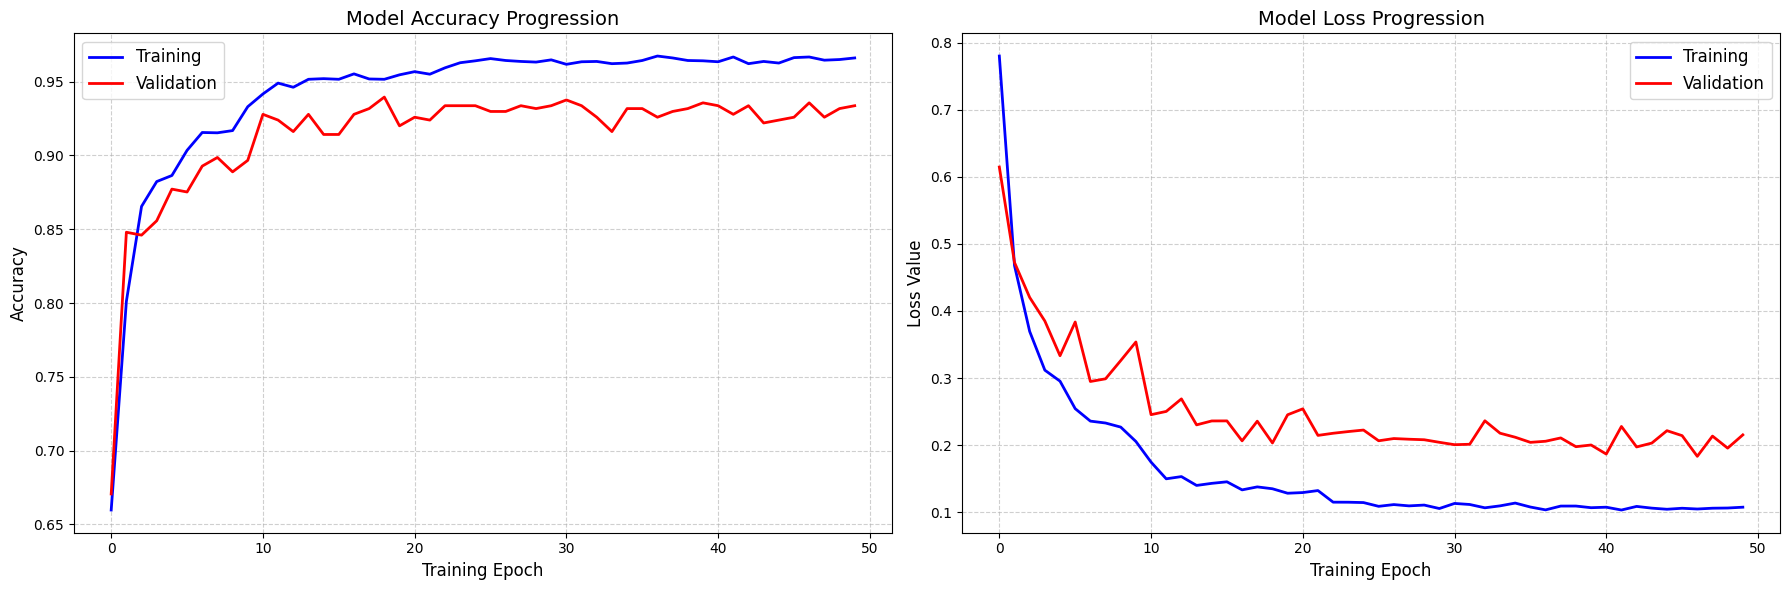

In [ ]:
# Define a function to plot the training metrics
def plot_training_metrics(history):
    """
    Creates and displays plots for training and validation metrics

    Args:
        history: Training history object returned by model.fit()
    """
    # Set up figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot accuracy metrics
    ax1.plot(history.history['accuracy'], 'b-', linewidth=2, label='Training')
    ax1.plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation')
    ax1.set_title('Model Accuracy Progression', fontsize=14)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_xlabel('Training Epoch', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(fontsize=12)

    # Plot loss metrics
    ax2.plot(history.history['loss'], 'b-', linewidth=2, label='Training')
    ax2.plot(history.history['val_loss'], 'r-', linewidth=2, label='Validation')
    ax2.set_title('Model Loss Progression', fontsize=14)
    ax2.set_ylabel('Loss Value', fontsize=12)
    ax2.set_xlabel('Training Epoch', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(fontsize=12)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

# Generate training metric visualizations
plot_training_metrics(training_history)
